# Plot1 - CarbonSavings vs. MakeSpan

## Line plot and Box plot

In [106]:
import pandas as pd
import glob
import os
location = "AU-SA"
# location = "California"
#############
# folder_type = "Homogen"
folder_type = "Heterogen"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExp/{folder_type}/{location}/Uniform Random Job Arrival"
num_servers = 5

# Define the pattern
pattern = "10J_5S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4320, 23)


In [107]:
df_logs = df_union[["Instance", "IsCarbonAware", "Horizon", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)"]]

In [108]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g)
0,0,False,192,192,104,1.0,104,19289.25
1,0,True,192,104,104,1.0,104,13072.75
2,0,True,192,156,104,1.5,145,11037.25
3,0,True,192,192,104,2.0,172,11714.50
4,1,False,192,192,119,1.0,119,28125.50
5,1,True,192,119,119,1.0,119,18352.00
6,1,True,192,179,119,1.5,135,18847.75
7,1,True,192,192,119,2.0,127,19502.25
8,2,False,192,192,113,1.0,113,24816.25
9,2,True,192,113,113,1.0,113,22616.50


Average of the optimal makespan

In [109]:
import numpy as np
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Makespan"]]
np.average(baseline["Makespan"])
# np.std(baseline["Makespan"])

np.float64(100.30092592592592)

In [110]:

# First, get baseline carbon consumption per instance where IsCarbonAware is False
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)"]]
baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon"})
# Merge it back to original df to align baseline carbon for each instance
df_logs = df_logs.merge(baseline, on="Instance", how="left")
# Calculate savings
df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
df_logs.drop(columns=["BaselineCarbon"], inplace=True)
# Optional: round to 2 decimal places
df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)


In [111]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),CarbonSavings(%)
0,0,False,192,192,104,1.0,104,19289.25,0.00
1,0,True,192,104,104,1.0,104,13072.75,32.23
2,0,True,192,156,104,1.5,145,11037.25,42.78
3,0,True,192,192,104,2.0,172,11714.50,39.27
4,1,False,192,192,119,1.0,119,28125.50,0.00
5,1,True,192,119,119,1.0,119,18352.00,34.75
6,1,True,192,179,119,1.5,135,18847.75,32.99
7,1,True,192,192,119,2.0,127,19502.25,30.66
8,2,False,192,192,113,1.0,113,24816.25,0.00
9,2,True,192,113,113,1.0,113,22616.50,8.86


In [112]:
import ast
df_utilization = df_union [["Instance", "IsCarbonAware", "SlackCoeff", "MaxMakeSpan", "MinMakeSpan", "Makespan"] + [f"Server{i}" for i in range(num_servers)]]
df_utilization = df_utilization[df_utilization["IsCarbonAware"] == True]
server_columns = [col for col in df_utilization.columns if col.startswith('Server')]
for col in server_columns:
    df_utilization[col] = df_utilization[col].apply(ast.literal_eval)

In [113]:
slack_coeffs = list(df_utilization["SlackCoeff"].unique())
util_ratios = {} # per instance
util_final_ratio = {} # average over all instances
for slack_coeff in slack_coeffs:
    df = df_utilization[df_utilization["SlackCoeff"] == slack_coeff]
    util_ratios[slack_coeff] = [] # per instance
    for index, row in df.iterrows(): # per instance
        servers_utilization = {}
        for serverID in range(num_servers):
            server_status = row[f"Server{serverID}"]
            server_util = 0
            for [job_id, operation_id, start, end] in server_status:
                server_util += (end - start) / row["MaxMakeSpan"]
            servers_utilization[serverID] = server_util
        # print(servers_utilization)
        util_ratios[slack_coeff].append(np.average(list(servers_utilization.values())))
        # print(util_ratios)
        # raise Exception ("S")
    util_final_ratio[slack_coeff] = round(np.average(util_ratios[slack_coeff]) * 100, 2)
# Convert keys and values to regular Python float
util_final_ratio = {float(k): float(v) for k, v in util_final_ratio.items()}
        

In [114]:
util_final_ratio

{1.0: 40.95, 1.5: 29.62, 2.0: 22.81}

In [115]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_plot = df_filtered.groupby("SlackCoeff")["CarbonSavings(%)"].mean().reset_index()
df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [116]:
df_plot

,SlackCoeff,CarbonSavings(%),UtilizationRatio
0,1.0,25.017954,40.95
1,1.5,46.161444,29.62
2,2.0,44.950528,22.81


In [117]:
import pandas as pd

# Filter for carbon-aware runs only
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_box["MakeSpanRatio"] = df_box["SlackCoeff"]
df_box["MakeSpanRatio"] = df_box["MakeSpanRatio"].astype(str)

In [118]:
df_box.head(8)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),CarbonSavings(%),MakeSpanRatio
1,0,True,192,104,104,1.0,104,13072.75,32.23,1.0
2,0,True,192,156,104,1.5,145,11037.25,42.78,1.5
3,0,True,192,192,104,2.0,172,11714.50,39.27,2.0
5,1,True,192,119,119,1.0,119,18352.00,34.75,1.0
6,1,True,192,179,119,1.5,135,18847.75,32.99,1.5
7,1,True,192,192,119,2.0,127,19502.25,30.66,2.0
9,2,True,192,113,113,1.0,113,22616.50,8.86,1.0
10,2,True,192,170,113,1.5,169,17920.00,27.79,1.5


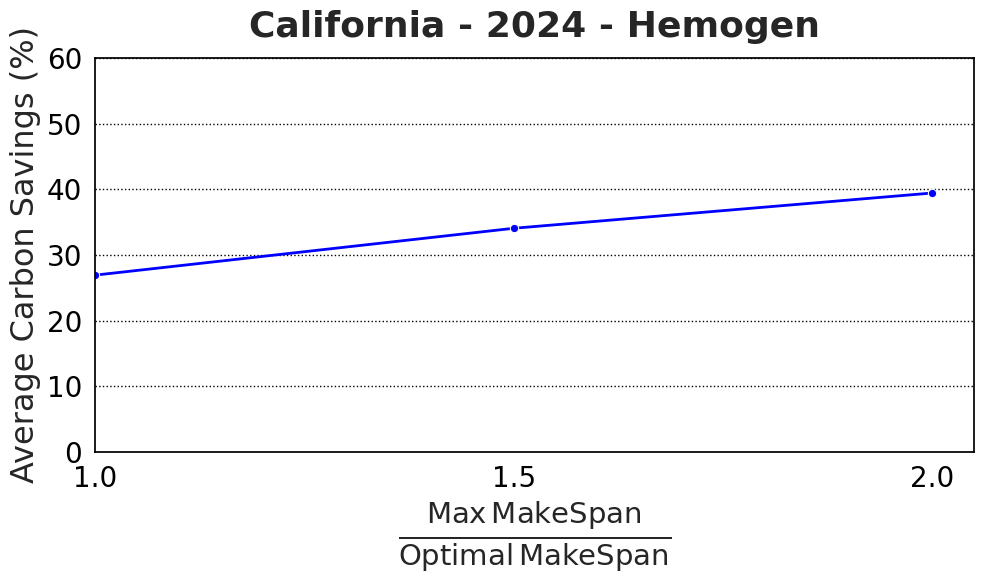

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

location = "California"
# location = "AU-SA"
############
# folder_type = "Heterogen"
folder_type = "Homogen"
###########
save_fig = True

# Seaborn & matplotlib styling
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Ensure 'x_label' is treated as string (categorical)
df_plot["SlackCoeff"] = df_plot["SlackCoeff"].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_plot,
    x="SlackCoeff",
    y="CarbonSavings(%)",
    marker="o",
    linewidth=2,
    color="blue"
)

# Labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Average Carbon Savings (%)", fontsize=23)

# Axis limits and tick font sizes
ax.set_ylim(0, 60)
ax.set_xlim(0)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Add minor ticks on y-axis every 2 units
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid settings
ax.grid(axis='x', visible=False)  # No x-grid
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)

# Black border and ticks
ax.tick_params(axis='both', color='black', labelcolor='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    
ax.set_title(f"{location} - 2024 - {folder_type}", fontsize=26, fontweight="bold", pad=15)

plt.tight_layout()
if save_fig:
    plt.savefig(f"./GeneralExp/{folder_type}/LinePlot-{location}.png", dpi=300, bbox_inches='tight')
plt.show()

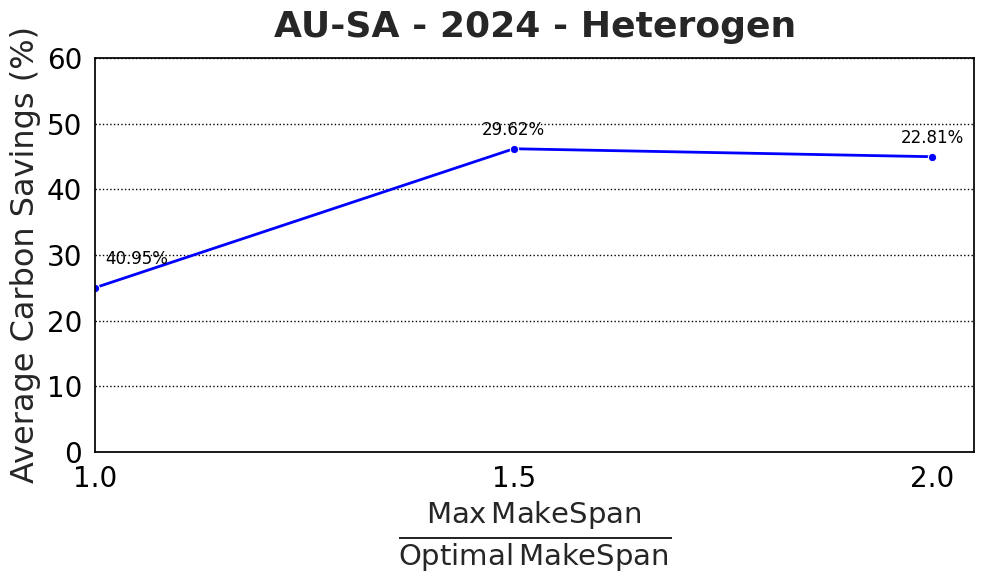

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# location = "California"
location = "AU-SA"
#############
# folder_type = "Homogen"
folder_type = "Heterogen"
##############
save_fig = True

# Seaborn & matplotlib styling
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Ensure 'x_label' is treated as string (categorical)
df_plot["SlackCoeff"] = df_plot["SlackCoeff"].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_plot,
    x="SlackCoeff",
    y="CarbonSavings(%)",
    marker="o",
    linewidth=2,
    color="blue"
)

# Labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Average Carbon Savings (%)", fontsize=23)

# Axis limits and tick font sizes
ax.set_ylim(0, 60)
ax.set_xlim(0)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Add minor ticks on y-axis every 2 units
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid settings
ax.grid(axis='x', visible=False)  # No x-grid
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)

# Black border and ticks
ax.tick_params(axis='both', color='black', labelcolor='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    
ax.set_title(f"{location} - 2024 - {folder_type}", fontsize=26, fontweight="bold", pad=15)

# Annotate each point with UtilizationRatio
for index, row in df_plot.iterrows():
    utilization_ratio = row['UtilizationRatio']
    x_pos = row['SlackCoeff']
    y_pos = row['CarbonSavings(%)']
    
    # If it's the first point, adjust it slightly to the right
    if index == 0:
        ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                color='black', fontsize=12, ha='center', va='bottom')
    else:
        ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                color='black', fontsize=12, ha='center', va='bottom')

plt.tight_layout()
if save_fig:
    plt.savefig(f"./GeneralExp/{folder_type}/LinePlot-{location}-UtilRatio.png", dpi=300, bbox_inches='tight')
plt.show()

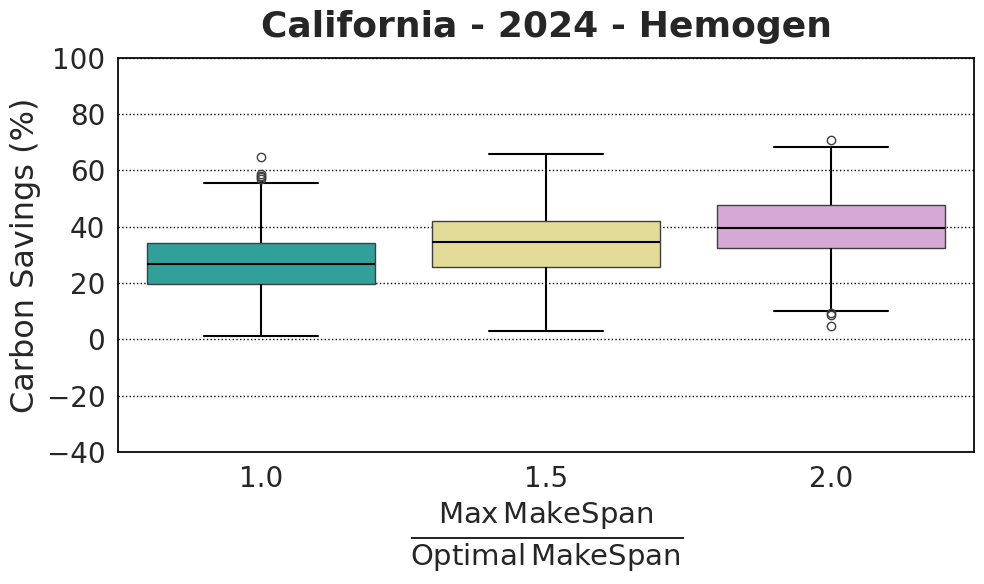

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

location = "California"
# location = "Australia-South"
# folder_type = "Heterogen"
folder_type = "Homogen"
save_fig = True
# Setup
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Dynamically match colors to number of unique categories
unique_labels = sorted(df_box["SlackCoeff"].unique())
inner_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid"]
palette = inner_colors[:len(unique_labels)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
box = sns.boxplot(
    data=df_box,
    x="SlackCoeff",
    y="CarbonSavings(%)",
    hue="SlackCoeff",
    palette=palette,
    dodge=False,
    legend=False
)

# Axis labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Carbon Savings (%)", fontsize=23)

# Axis ticks and limits
ax.set_ylim(-40, 100)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Minor ticks
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid & borders
ax.grid(axis='x', visible=False)
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Box edges and medians
for i, patch in enumerate(ax.artists):
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)
    patch.set_facecolor(palette[i % len(palette)])
for line in ax.lines:
    line.set_color("black")
    line.set_linewidth(1.5)
ax.set_title(f"{location} - 2024 - {folder_type}", fontsize=26, fontweight="bold", pad=15)
plt.tight_layout()
if save_fig:
    plt.savefig(f"./GeneralExp/{folder_type}/BoxPlot-{location}.png", dpi=300, bbox_inches='tight')
plt.show()

## Line plot + Utilization

In [17]:
import pandas as pd
import glob
import os
# location = "Australia-WA"
location = "California"
folder_type = "Homogen"
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExp/{folder_type}/{location}/Uniform Random Job Arrival"
num_servers = 5

# Define the pattern
pattern = "10J_5S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4320, 23)


In [16]:
df_union.head(2)

,ElapsedTime,Datetime,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),...,ServerPower,EpochDuration(min),SolverTimer(min),JobIndex,JobArrivalEpoch,Server0,Server1,Server2,Server3,Server4
0,0:00:00,2024-01-01,0,False,192,192,111,1.0,111,12887.25,...,"[1, 1, 1, 1, 1]",15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[654, 0, 3, 10], [114, 0, 13, 29], [114, 1, 5...","[[654, 2, 21, 24], [25, 2, 49, 55], [759, 0, 1...","[[25, 1, 32, 35], [759, 1, 20, 22], [228, 1, 4...","[[142, 0, 81, 83], [142, 1, 83, 84]]","[[654, 1, 10, 21], [754, 1, 95, 104]]"
1,0:01:06,2024-01-01,0,True,192,111,111,1.0,111,7994.25,...,"[1, 1, 1, 1, 1]",15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[654, 0, 72, 79], [228, 1, 79, 83], [228, 2, ...","[[114, 1, 92, 93], [25, 0, 77, 80], [759, 0, 7...","[[114, 0, 72, 88], [25, 2, 90, 96], [142, 0, 8...","[[25, 1, 87, 90], [759, 2, 82, 87], [281, 0, 7...","[[654, 1, 79, 90], [654, 2, 90, 93], [114, 2, ..."


In [49]:
import ast
df_utilization = df_union [["Instance", "IsCarbonAware", "SlackCoeff", "MaxMakeSpan", "MinMakeSpan", "Makespan"] + [f"Server{i}" for i in range(num_servers)]]
df_utilization = df_utilization[df_utilization["IsCarbonAware"] == True]
server_columns = [col for col in df_utilization.columns if col.startswith('Server')]
for col in server_columns:
    df_utilization[col] = df_utilization[col].apply(ast.literal_eval)

In [50]:
df_utilization.head(3)

,Instance,IsCarbonAware,SlackCoeff,MaxMakeSpan,MinMakeSpan,Makespan,Server0,Server1,Server2,Server3,Server4
1,0,True,1.0,111,111,111,"[[654, 0, 72, 79], [228, 1, 79, 83], [228, 2, ...","[[114, 1, 92, 93], [25, 0, 77, 80], [759, 0, 7...","[[114, 0, 72, 88], [25, 2, 90, 96], [142, 0, 8...","[[25, 1, 87, 90], [759, 2, 82, 87], [281, 0, 7...","[[654, 1, 79, 90], [654, 2, 90, 93], [114, 2, ..."
2,0,True,1.5,167,111,167,"[[654, 0, 69, 76], [114, 1, 164, 165], [114, 2...","[[114, 0, 79, 95], [250, 1, 78, 79], [228, 0, ...","[[281, 2, 80, 82], [228, 2, 82, 95], [142, 2, ...","[[759, 0, 75, 78], [250, 0, 71, 75], [250, 2, ...","[[654, 1, 76, 87], [654, 2, 160, 163], [25, 1,..."
3,0,True,2.0,192,111,184,"[[114, 1, 91, 92], [114, 2, 164, 166], [25, 2,...","[[654, 2, 165, 168], [114, 0, 75, 91], [281, 2...","[[228, 0, 78, 92], [228, 2, 168, 181]]","[[654, 0, 75, 82], [250, 2, 172, 180], [142, 0...","[[654, 1, 82, 93], [25, 0, 72, 75], [25, 1, 78..."


In [43]:
slack_coeffs = list(df_utilization["SlackCoeff"].unique())

In [62]:
util_ratios = {} # per instance
util_final_ratio = {} # average over all instances
for slack_coeff in slack_coeffs:
    df = df_utilization[df_utilization["SlackCoeff"] == slack_coeff]
    util_ratios[slack_coeff] = [] # per instance
    for index, row in df.iterrows(): # per instance
        servers_utilization = {}
        for serverID in range(num_servers):
            server_status = row[f"Server{serverID}"]
            server_util = 0
            for [job_id, operation_id, start, end] in server_status:
                server_util += (end - start) / row["MaxMakeSpan"]
            servers_utilization[serverID] = server_util
        # print(servers_utilization)
        util_ratios[slack_coeff].append(np.average(list(servers_utilization.values())))
        # print(util_ratios)
        # raise Exception ("S")
    util_final_ratio[slack_coeff] = round(np.average(util_ratios[slack_coeff]) * 100, 2)
# Convert keys and values to regular Python float
util_final_ratio = {float(k): float(v) for k, v in util_final_ratio.items()}
        

In [63]:
util_final_ratio

{1.0: 35.7, 1.5: 23.93, 2.0: 20.93}